# Notebook 01: ODE Model Simulation
Implements the deterministic 5-equation mean-field system, sweeps parameter space, and maps the stability boundary.


### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*


In [1]:
import sys
sys.path.append('..')
from src.pendulum_model import PendulumSimulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Run Standard Scenarios
We load pre-configured scenarios representing different theoretical regimes.


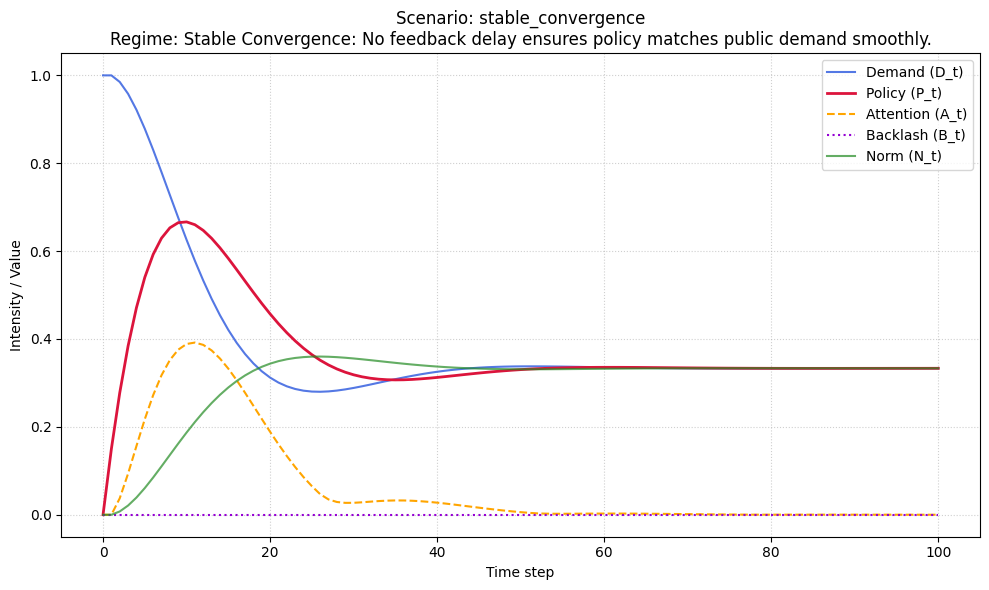

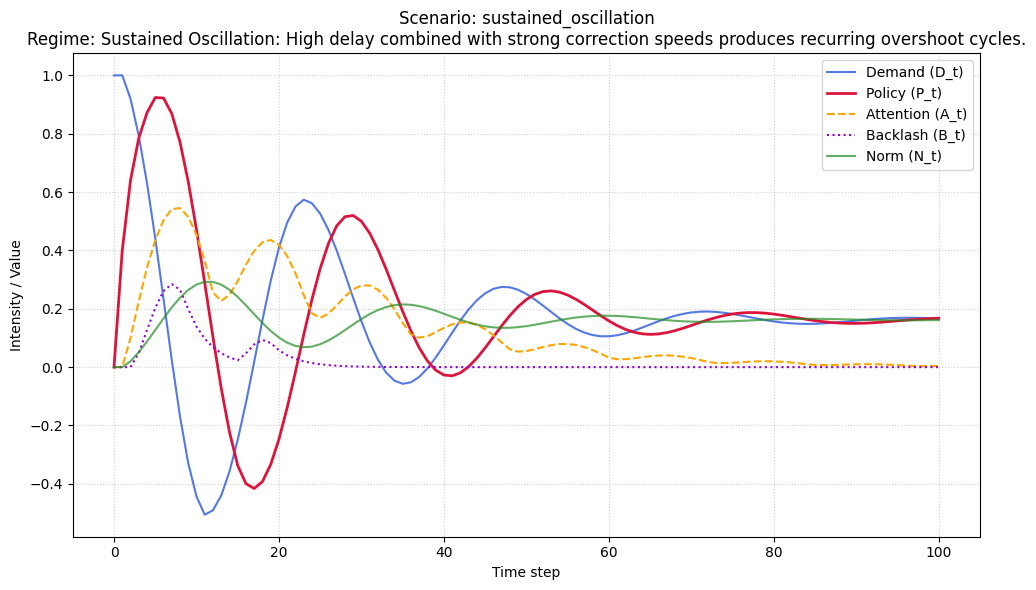

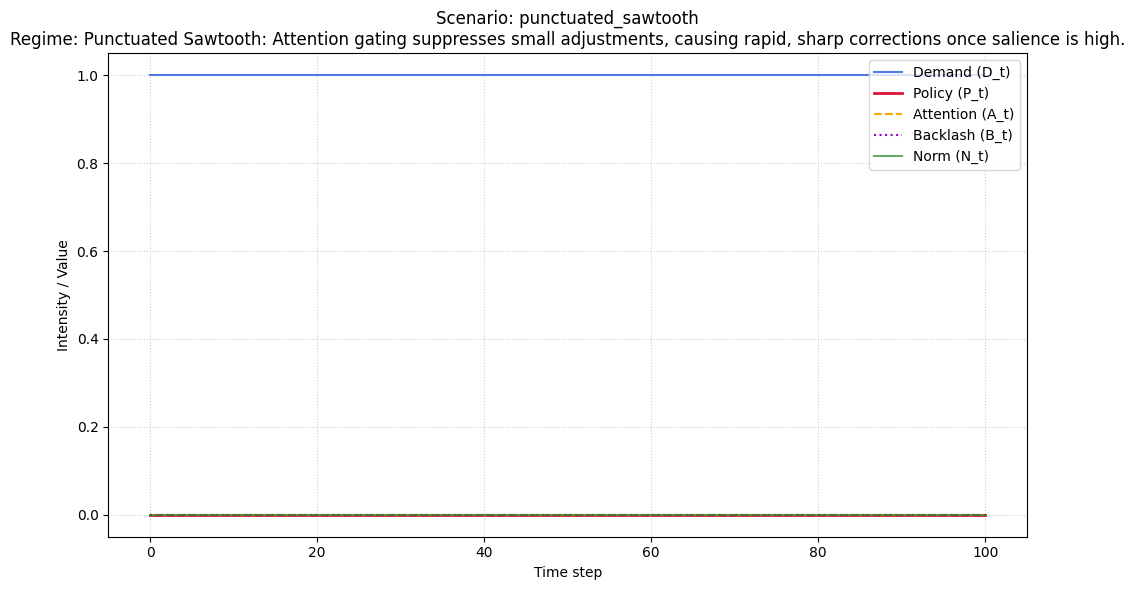

In [2]:
scenarios = ['stable_convergence', 'sustained_oscillation', 'punctuated_sawtooth']
for name in scenarios:
    sim = PendulumSimulation.from_scenario(name)
    sim.run(steps=100)
    fig = sim.plot_time_series(title=f'Scenario: {name}')
    plt.show()


## 2. Stability Boundary Parameter Sweep
We sweep over $\tau$ (delay lag) and $\lambda$ (correction speed) to map the boundary between stable convergence and cycles.


In [3]:
sim = PendulumSimulation(alpha=0.2, nu=0.05)
df_sweep = sim.parameter_sweep(tau_range=list(range(6)), lambda_range=list(np.linspace(0.05, 0.9, 10)))
print(df_sweep.head(10))


   tau    lambda  amplitude_std  sign_changes  final_value      regime
0    0  0.050000   5.263846e-03             3     0.192636  convergent
1    0  0.144444   9.647274e-04             5     0.189568  convergent
2    0  0.238889   8.186878e-05             6     0.188798  convergent
3    0  0.333333   3.216363e-06             8     0.188651  convergent
4    0  0.427778   2.442961e-07             8     0.188743  convergent
5    0  0.522222   4.523163e-09             6     0.188937  convergent
6    0  0.616667   7.179119e-11             5     0.189174  convergent
7    0  0.711111   1.833649e-12             2     0.189423  convergent
8    0  0.805556   8.589483e-15             1     0.189669  convergent
9    0  0.900000   1.980222e-16             0     0.189903  convergent


C:\Users\admir\AppData\Local\Temp\ipykernel_2300\638988088.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(
C:\Users\admir\AppData\Local\Temp\ipykernel_2300\638988088.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


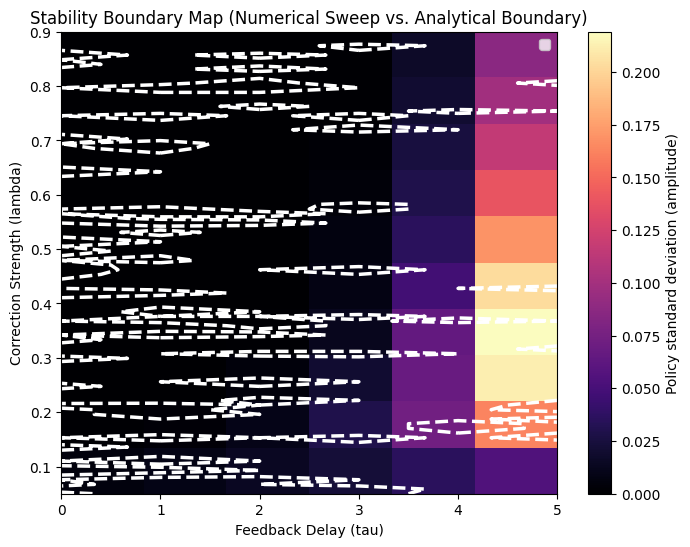

In [4]:
# 1. Run numerical sweep pivot
pivot = df_sweep.pivot(index='lambda', columns='tau', values='amplitude_std')

# 2. Run analytical stability sweep over a finer grid for a smooth boundary
df_analytical = sim.analytical_stability_sweep(
    tau_range=list(range(6)),
    lambda_range=list(np.linspace(0.05, 0.9, 100))
)
pivot_analytical = df_analytical.pivot(index='lambda', columns='tau', values='spectral_radius')

# 3. Plot stability boundary map
plt.figure(figsize=(8, 6))
# Plot numerical sweep as heatmap
plt.imshow(pivot, aspect='auto', origin='lower', extent=[0, 5, 0.05, 0.9], cmap='magma')
plt.colorbar(label='Policy standard deviation (amplitude)')

# Overlay analytical stability boundary (contour where spectral radius = 1.0)
tau_grid = pivot_analytical.columns
lambda_grid = pivot_analytical.index
plt.contour(
    tau_grid, lambda_grid, pivot_analytical.values,
    levels=[1.0], colors='white', linewidths=2.5, linestyles='--',
    label='Analytical Boundary (spectral radius = 1.0)'
)

plt.xlabel('Feedback Delay (tau)')
plt.ylabel('Correction Strength (lambda)')
plt.title('Stability Boundary Map (Numerical Sweep vs. Analytical Boundary)')
plt.legend(loc='upper right')
plt.show()


## 3. The Theory-to-Empirics Bridge

It is important to clarify how this mathematical Ordinary Differential Equation (ODE) model connects to the empirical econometric analysis in the subsequent notebooks:

1. **Generative Theoretical Model**: The 5-equation ODE model is used as a generative theoretical framework to explore the system's qualitative dynamics (such as stable convergence, sustained oscillations, and punctuated sawtooth patterns). We do **not** directly estimate or calibrate the structural ODE parameters from the state-year panel data. 
2. **Reduced-Form Implications**: The empirical regression models in Notebook 07 and 08 test the reduced-form implications of this theoretical feedback structure: 
   - **H1 (Thermostatic Feedback)**: Tests whether policy intensity level predicts later backlash (policy-to-backlash link) and whether backlash predicts a policy correction (backlash-to-policy rollback link).
   - **H7 (Institutional Dampening)**: Tests if federal waivers act as safety valves that dampen these dynamic links.
3. **Parameter Mapping**: While the ODE uses continuous unbounded variables ($P_t, N_t \in [-2.0, 2.0]$), the empirical panel indicators are standardized composites. The theoretical simulation acts as a conceptual roadmap rather than a direct statistical fit.